# Task - 1: Data Exploration and Preprocessing

## Importing required libraries

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.stats as st
import nbformat

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None) # for showing all columns
pd.set_option('display.expand_frame_repr', False) # to prevent column header wrapping
pd.set_option('display.float_format', '{:.3f}'.format) # Float precision

sns.set_style("whitegrid")

## Loading data

In [70]:
import os

print(os.getcwd())
print(os.listdir())

d:\portfolio_projects\ML_projects\project-8-restaurant-rating-prediction\Notebooks\EDA
['01_EDA.ipynb', '02_EDA.ipynb', '03_EDA.ipynb', '04_regression_analysis.ipynb', 'utils', '__init__.py']


In [71]:
from pathlib import Path

base_path = Path.cwd().parents[1]  # go up two levels
file_path = base_path / "Restaurant_Data" / "Dataset.csv"
df = pd.read_csv(file_path)

## Initial Inspection

In [72]:
df.head(10)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.028,14.565,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.800,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014,14.554,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.500,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.057,14.581,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.400,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056,14.585,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.900,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.058,14.584,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.800,Dark Green,Excellent,229
5,18189371,Din Tai Fung,162,Mandaluyong City,"Ground Floor, Mega Fashion Hall, SM Megamall, ...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056,14.584,Chinese,1000,Botswana Pula(P),No,No,No,No,3,4.400,Green,Very Good,336
6,6300781,Buffet 101,162,Pasay City,"Building K, SM By The Bay, Sunset Boulevard, M...","SM by the Bay, Mall of Asia Complex, Pasay City","SM by the Bay, Mall of Asia Complex, Pasay Cit...",120.980,14.531,"Asian, European",2000,Botswana Pula(P),Yes,No,No,No,4,4.000,Green,Very Good,520
7,6301290,Vikings,162,Pasay City,"Building B, By The Bay, Seaside Boulevard, Mal...","SM by the Bay, Mall of Asia Complex, Pasay City","SM by the Bay, Mall of Asia Complex, Pasay Cit...",120.979,14.540,"Seafood, Filipino, Asian, European",2000,Botswana Pula(P),Yes,No,No,No,4,4.200,Green,Very Good,677
8,6300010,Spiral - Sofitel Philippine Plaza Manila,162,Pasay City,"Plaza Level, Sofitel Philippine Plaza Manila, ...","Sofitel Philippine Plaza Manila, Pasay City","Sofitel Philippine Plaza Manila, Pasay City, P...",120.980,14.553,"European, Asian, Indian",6000,Botswana Pula(P),Yes,No,No,No,4,4.900,Dark Green,Excellent,621
9,6314987,Locavore,162,Pasig City,"Brixton Technology Center, 10 Brixton Street, ...",Kapitolyo,"Kapitolyo, Pasig City",121.057,14.572,Filipino,1100,Botswana Pula(P),Yes,No,No,No,3,4.800,Dark Green,Excellent,532


In [73]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 9551
Number of columns: 21


In [74]:
df.size

200571

**Observation:**
- There are total 9551 rows and 21 columns in the give dataset.

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

**Observation:**
- There are total 8 numerical columns and 13 categorical columns in the given dataset.
- Numerical columns do not require any conversion.
- In further analysis, we may convert the follwoing 4 categorical columns into boolean data type if needed:
  1.  ***Has Table booking***
  2.  ***Has Online delivery***
  3.  ***Is delivering now***
  4.  ***Switch to order menu***
- As we can see, some of the columns in the dataset contains some null values which demands further inspection.

In [76]:
# missing value inspection
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

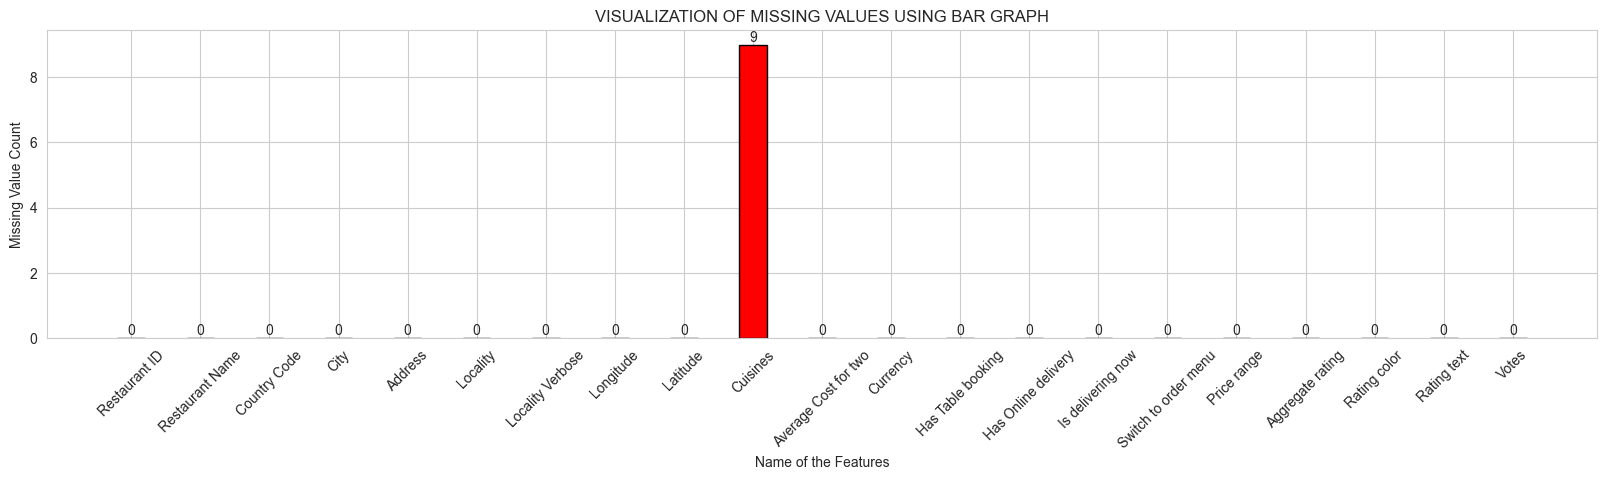

In [77]:
# visualization
plt.figure(figsize=(20,4))
bars = plt.bar(x=df.isnull().sum().index,
       height=df.isnull().sum().values,
       edgecolor='black',
       width=0.4,
       color='red')
plt.bar_label(bars,
              labels=df.isnull().sum().values,
              label_type='edge')
plt.xlabel('Name of the Features')
plt.xticks(rotation=45)
plt.ylabel('Missing Value Count')
plt.title('VISUALIZATION OF MISSING VALUES USING BAR GRAPH')
base_path = Path.cwd().parents[1]
file_path = base_path / "Notebooks" / "reports" / "missing_value_analysis.png"
plt.savefig(file_path, dpi=150, bbox_inches="tight")
plt.show()

**Observation:**
- Only one column i.e. "Cuisines" contains 9 missings values which needs to be dealt with accordingly.

In [78]:
df[df['Cuisines'].isnull()].reset_index(drop=True)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,17284105,Cookie Shoppe,216,Albany,"115 N Jackson St, Albany, GA 31701",Albany,"Albany, Albany",-84.154,31.577,NaN,0,Dollar($),No,No,No,No,1,3.400,Orange,Average,34
1,17284211,Pearly's Famous Country Cookng,216,Albany,"814 N Slappey Blvd, Albany, GA 31701",Albany,"Albany, Albany",-84.176,31.588,NaN,0,Dollar($),No,No,No,No,1,3.400,Orange,Average,36
2,17284158,Jimmie's Hot Dogs,216,Albany,"204 S Jackson St, Albany, GA 31701",Albany,"Albany, Albany",-84.153,31.575,NaN,10,Dollar($),No,No,No,No,1,3.900,Yellow,Good,160
3,17374552,Corkscrew Cafe,216,Gainesville,"51 W Main St, Dahlonega, GA 30533",Dahlonega,"Dahlonega, Gainesville",-83.986,34.532,NaN,40,Dollar($),No,No,No,No,3,3.900,Yellow,Good,209
4,17501439,Dovetail,216,Macon,"543 Cherry St, Macon, GA 31201",Macon,"Macon, Macon",-83.628,32.836,NaN,40,Dollar($),No,No,No,No,3,3.800,Yellow,Good,102
5,17606621,HI Lite Bar & Lounge,216,Miller,"109 N Broadway Ave, Miller, SD 57362",Miller,"Miller, Miller",-98.989,44.516,NaN,0,Dollar($),No,No,No,No,1,3.400,Orange,Average,11
6,17059060,Hillstone,216,Orlando,"215 South Orlando Avenue, Winter Park, FL 32789",Winter Park,"Winter Park, Orlando",-81.365,28.597,NaN,40,Dollar($),No,No,No,No,3,4.400,Green,Very Good,1158
7,17142698,Leonard's Bakery,216,Rest of Hawaii,"933 Kapahulu Ave, Honolulu, HI 96816",Kaimuki,"Kaimuki, Rest of Hawaii",-157.813,21.285,NaN,10,Dollar($),No,No,No,No,1,4.700,Dark Green,Excellent,707
8,17616465,Tybee Island Social Club,216,Savannah,"1311 Butler Ave, Tybee Island, GA 31328",Tybee Island,"Tybee Island, Savannah",-80.848,31.996,NaN,10,Dollar($),No,No,No,No,1,3.900,Yellow,Good,309


In [79]:
result = str(np.round(df['Cuisines'].isnull().sum()/len(df)*100,2))+"%"
print("% missing values in the Cuisines column: {}".format(result))

% missing values in the Cuisines column: 0.09%


### Missing value handling strategies:
- Dropping the rows with missing values
- Missing value Imputation
  - Forwardfill or Backwardfill
  - Mode imputation
  - We can create a separate category - "missing" so that ML model can analyze the pattern.
  - We can create a separate column - "Cuisines available" and fill that column with "True" for Cuisines not null and "False" for Cuisines null.

* As the missings values in the column is very small ~ 0.1%, so we can drop those rows with missing values.

In [80]:
df.dropna(axis=0, subset=["Cuisines"], inplace=True)
df.reset_index(drop=True, inplace=True)

In [81]:
# verifying
df[df['Cuisines'].isnull()].reset_index(drop=True)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes


In [82]:
# duplicate rows inspection
df[df.duplicated(keep=False)]

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes


**Observation:**
- There are no duplicated rows present in the given dataset.

## analyzing the distribution of the target variable - "Aggregate rating"

In [83]:
# Helper function to plot histograms based on the
# format of the `sessions` histogram
def histogrammer(column_str, median_text=True, mean_text=True, **kwargs):    # **kwargs = any keyword arguments
                                                             # from the sns.histplot() function
    
    plt.figure(figsize=(20,3))

    if (df[column_str].dtypes != 'str') and (df[column_str].dtypes != 'object'):
        median=round(df[column_str].median(), 1)
        mean=round(df[column_str].mean(), 1)
        skewness=round(df[column_str].skew(), 1)
        kurtosis=round(st.kurtosis(df[column_str], fisher=False), 1)

        ax = sns.histplot(x=df[column_str], **kwargs)            # Plot the histogram
        plt.axvline(median, color='red', linestyle='--')         # Plot the median line
        plt.axvline(mean, color='green', linestyle='--')
        
        if (median_text==True) and (mean_text==True):                                    # Add median text unless set to False
            print("Skewness: {}\nKurtosis: {}".format(skewness, kurtosis))
            ax.text(0.25, 0.85, f'median={median}', color='red',
                ha='left', va='top', transform=ax.transAxes)
            ax.text(0.25, 0.95, f'mean={mean}', color='green',
                ha='left', va='top', transform=ax.transAxes)
        else:
            print('Median:', median)
            print('Mean:', mean)
    
    else:
        mode = df[column_str].mode()[0]
        print('Mode:', mode)
        sns.histplot(x=df[column_str], **kwargs)
        plt.xticks(rotation=90)
    
    plt.title(f'{column_str} histogram');

Skewness: -1.0
Kurtosis: 2.4


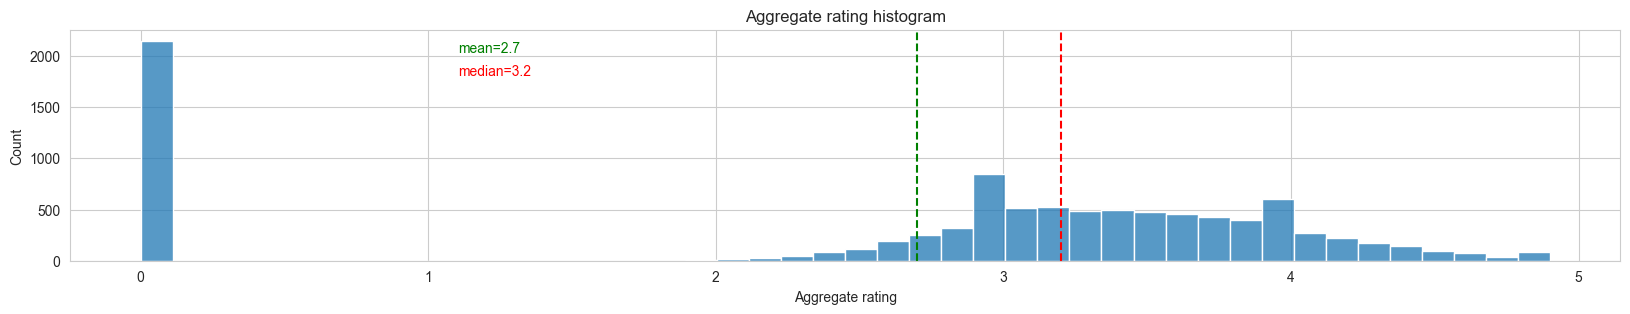

In [84]:
histogrammer(column_str="Aggregate rating")

**Observation:**
- As we can see, there is a huge class imbalance in the aggregate rating column.

In [85]:
df['Aggregate rating'].nunique()

33

In [86]:
df['Aggregate rating'].unique()

array([4.8, 4.5, 4.4, 4.9, 4. , 4.2, 4.3, 3.6, 4.7, 3. , 3.8, 3.7, 3.2,
       3.1, 0. , 4.1, 3.3, 4.6, 3.9, 3.4, 3.5, 2.2, 2.9, 2.4, 2.6, 2.8,
       2.1, 2.7, 2.5, 1.8, 2. , 2.3, 1.9])

In [87]:
df['Aggregate rating'].value_counts()

Aggregate rating
0.000    2148
3.200     522
3.100     519
3.400     495
3.300     483
3.500     480
3.000     468
3.600     458
3.700     427
3.800     399
2.900     381
3.900     332
2.800     315
4.100     274
4.000     266
2.700     250
4.200     221
2.600     191
4.300     174
4.400     143
2.500     110
4.500      95
2.400      87
4.600      78
4.900      61
2.300      47
4.700      41
2.200      27
4.800      25
2.100      15
2.000       7
1.900       2
1.800       1
Name: count, dtype: int64

In [88]:
df['Aggregate rating'].value_counts(normalize=True)*100

Aggregate rating
0.000   22.511
3.200    5.471
3.100    5.439
3.400    5.188
3.300    5.062
3.500    5.030
3.000    4.905
3.600    4.800
3.700    4.475
3.800    4.182
2.900    3.993
3.900    3.479
2.800    3.301
4.100    2.872
4.000    2.788
2.700    2.620
4.200    2.316
2.600    2.002
4.300    1.824
4.400    1.499
2.500    1.153
4.500    0.996
2.400    0.912
4.600    0.817
4.900    0.639
2.300    0.493
4.700    0.430
2.200    0.283
4.800    0.262
2.100    0.157
2.000    0.073
1.900    0.021
1.800    0.010
Name: proportion, dtype: float64

In [89]:
rating_text_list = list(df['Rating text'].value_counts().index)
rating_text_list

['Average', 'Not rated', 'Good', 'Very Good', 'Excellent', 'Poor']

In [90]:
for text in rating_text_list:
    print(f"_________________{text}_________________")
    print("Category wise rating count:")
    print(df[df['Rating text']==text]['Aggregate rating'].value_counts())
    print("="*35)
    print("\n")

_________________Average_________________
Category wise rating count:
Aggregate rating
3.200    522
3.100    519
3.400    495
3.300    483
3.000    468
2.900    381
2.800    315
2.700    250
2.600    191
2.500    110
Name: count, dtype: int64


_________________Not rated_________________
Category wise rating count:
Aggregate rating
0.000    2148
Name: count, dtype: int64


_________________Good_________________
Category wise rating count:
Aggregate rating
3.500    480
3.600    458
3.700    427
3.800    399
3.900    332
Name: count, dtype: int64


_________________Very Good_________________
Category wise rating count:
Aggregate rating
4.100    274
4.000    266
4.200    221
4.300    174
4.400    143
Name: count, dtype: int64


_________________Excellent_________________
Category wise rating count:
Aggregate rating
4.500    95
4.600    78
4.900    61
4.700    41
4.800    25
Name: count, dtype: int64


_________________Poor_________________
Category wise rating count:
Aggregate rating
2.40

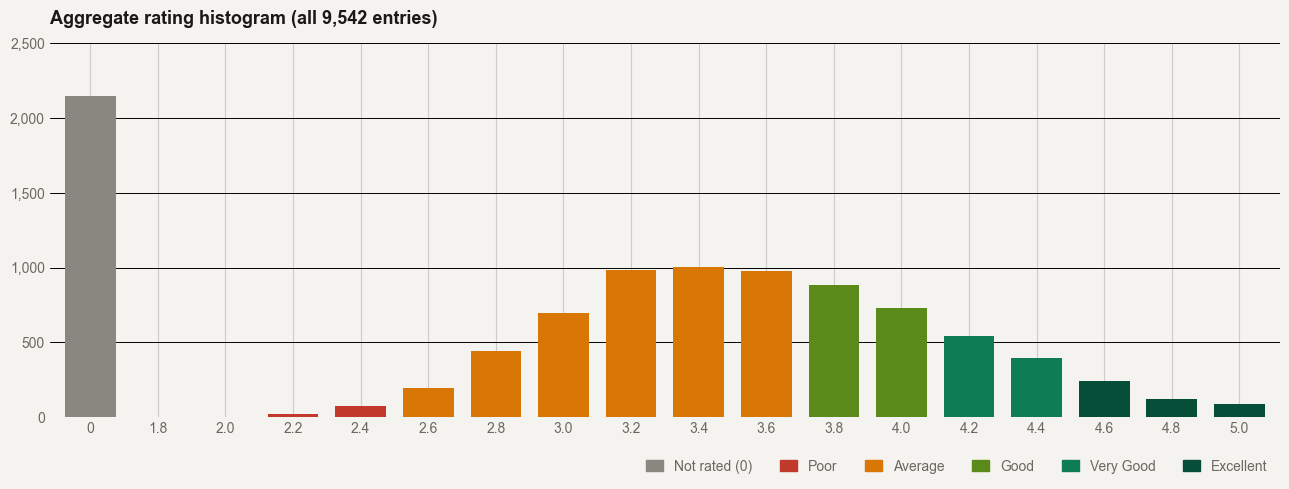

In [91]:
from utils.rating_histogram import histo

histo(df)

In [92]:
df_rating = df[['Aggregate rating', 'Rating text', 'Votes']]

df_rating.head()

,Aggregate rating,Rating text,Votes
0,4.800,Excellent,314
1,4.500,Excellent,591
2,4.400,Very Good,270
3,4.900,Excellent,365
4,4.800,Excellent,229


In [93]:
df_rating[df_rating['Rating text']=="Not rated"]['Votes'].value_counts()

Votes
0    1094
1     483
2     327
3     244
Name: count, dtype: int64

**Observation:**
- The zero / "Not Rated" problem is confirmed.
- Exactly 2,148 restaurants (22.5%) have a rating of 0.0, and the Rating text column labels them "Not rated" — these are definitely missing values, not true zero ratings.
- Crucially, 1,054 out of 2148 of these "Not rated" entries actually have non-zero votes, meaning some users voted but the platform never computed an aggregate. This makes them a distinct data quality issue.

In [94]:
print("________________________Count________________________")
print(df['Rating text'].value_counts())
print("="*35)
print("\n")
print("________________________% of all________________________")
print(df['Rating text'].value_counts(normalize=True)*100)
print("="*35)
print("\n")
print("________________________% of only rated________________________")
temp_df = df[df['Rating text'] != "Not rated"]
print(df['Rating text'].value_counts()/len(temp_df)*100)

________________________Count________________________
Rating text
Average      3734
Not rated    2148
Good         2096
Very Good    1078
Excellent     300
Poor          186
Name: count, dtype: int64


________________________% of all________________________
Rating text
Average     39.132
Not rated   22.511
Good        21.966
Very Good   11.297
Excellent    3.144
Poor         1.949
Name: proportion, dtype: float64


________________________% of only rated________________________
Rating text
Average     50.500
Not rated   29.051
Good        28.347
Very Good   14.579
Excellent    4.057
Poor         2.516
Name: count, dtype: float64


**Observation:**
- The "Average" class alone makes up 50.5% of all rated entries — a classic majority class dominance problem.
- "Excellent" is underrepresented at just 4.1%, with a 12.4:1 imbalance ratio between Average and Excellent.

In [95]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [96]:
df_cat = df[['Country Code', 'Has Table booking','Has Online delivery', 
            'Is delivering now', 'Switch to order menu','Price range']]
df_cat.rename(columns={
    'Has Table booking': 'Table Booking',
    'Has Online delivery': 'Online delivery',
    'Is delivering now': 'Delivering now',
    'Switch to order menu': 'Order menu'
}, inplace=True)

df_cat.head()

,Country Code,Table Booking,Online delivery,Delivering now,Order menu,Price range
0,162,Yes,No,No,No,3
1,162,Yes,No,No,No,3
2,162,Yes,No,No,No,4
3,162,No,No,No,No,4
4,162,Yes,No,No,No,4


In [97]:
for col in df_cat.columns:
    print(f"____________________{col}____________________")
    print(df_cat[col].value_counts())
    print("="*40)
    print('\n')

____________________Country Code____________________
Country Code
1      8652
216     425
215      80
30       60
189      60
214      60
148      40
208      34
14       24
162      22
94       21
166      20
184      20
191      20
37        4
Name: count, dtype: int64


____________________Table Booking____________________
Table Booking
No     8384
Yes    1158
Name: count, dtype: int64


____________________Online delivery____________________
Online delivery
No     7091
Yes    2451
Name: count, dtype: int64


____________________Delivering now____________________
Delivering now
No     9508
Yes      34
Name: count, dtype: int64


____________________Order menu____________________
Order menu
No    9542
Name: count, dtype: int64


____________________Price range____________________
Price range
1    4438
2    3113
3    1405
4     586
Name: count, dtype: int64




In [98]:
mapping = {1:'Budget' ,2:'Mid' ,3:'Premium' ,4:'Luxury'}
df_cat['Price range'] = df_cat['Price range'].replace(mapping)
df_cat.head(10)

,Country Code,Table Booking,Online delivery,Delivering now,Order menu,Price range
0,162,Yes,No,No,No,Premium
1,162,Yes,No,No,No,Premium
2,162,Yes,No,No,No,Luxury
3,162,No,No,No,No,Luxury
4,162,Yes,No,No,No,Luxury
5,162,No,No,No,No,Premium
6,162,Yes,No,No,No,Luxury
7,162,Yes,No,No,No,Luxury
8,162,Yes,No,No,No,Luxury
9,162,Yes,No,No,No,Premium


In [99]:
for col in df_cat.columns:
    print(f"____________________{col}____________________")
    print(df_cat[col].value_counts(normalize=True)*100)
    print("="*40)
    print('\n')

____________________Country Code____________________
Country Code
1     90.673
216    4.454
215    0.838
30     0.629
189    0.629
214    0.629
148    0.419
208    0.356
14     0.252
162    0.231
94     0.220
166    0.210
184    0.210
191    0.210
37     0.042
Name: proportion, dtype: float64


____________________Table Booking____________________
Table Booking
No    87.864
Yes   12.136
Name: proportion, dtype: float64


____________________Online delivery____________________
Online delivery
No    74.314
Yes   25.686
Name: proportion, dtype: float64


____________________Delivering now____________________
Delivering now
No    99.644
Yes    0.356
Name: proportion, dtype: float64


____________________Order menu____________________
Order menu
No   100.000
Name: proportion, dtype: float64


____________________Price range____________________
Price range
Budget    46.510
Mid       32.624
Premium   14.724
Luxury     6.141
Name: proportion, dtype: float64




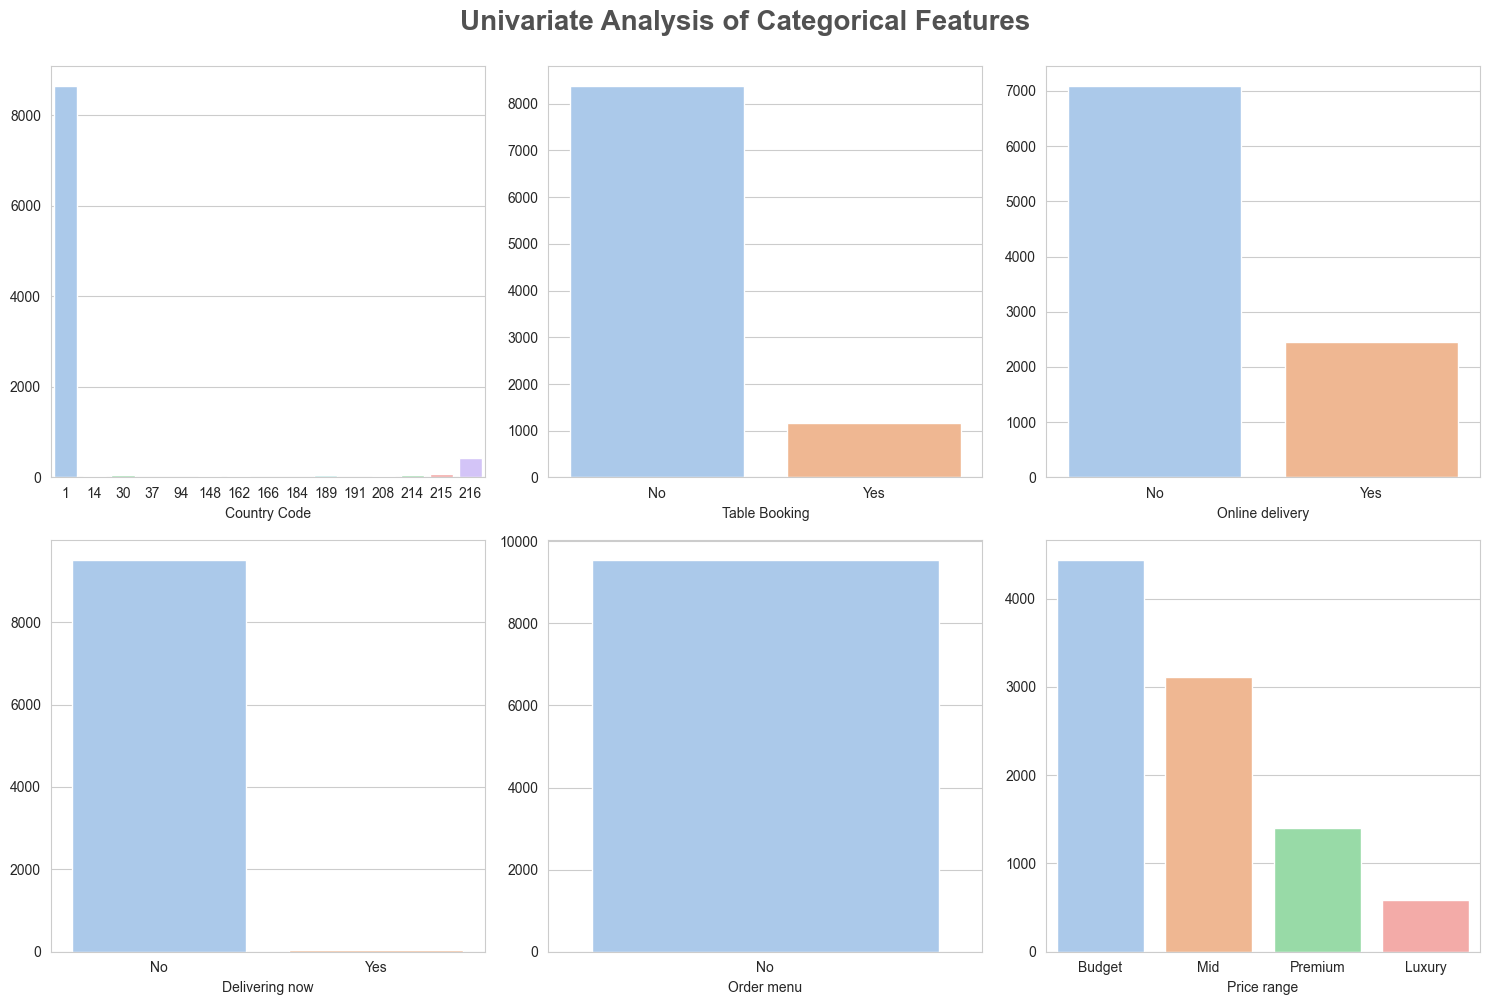

In [100]:
# Proportion of count data on categorical columns
plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1)
colors = sns.color_palette("pastel")
for i,col in enumerate(df_cat.columns, start=1):
    index = df_cat[col].value_counts().index
    values = df_cat[col].value_counts().values
    plt.subplot(2, 3, i)
    sns.barplot(x=index,
               y=values,
               palette=colors
               )
    plt.xlabel(col)
    plt.tight_layout()
base_path = Path.cwd().parents[1]
file_path = base_path / "Notebooks" / "reports" / "Univariate_analysis_categorical_features.png"
plt.savefig(file_path, dpi=150, bbox_inches="tight");

In [101]:
df[df['Country Code']==1]['City'].nunique()

43

In [102]:
df[df['Country Code']==1]['City'].unique()

array(['Agra', 'Ahmedabad', 'Allahabad', 'Amritsar', 'Aurangabad',
       'Bangalore', 'Bhopal', 'Bhubaneshwar', 'Chandigarh', 'Chennai',
       'Coimbatore', 'Dehradun', 'Faridabad', 'Ghaziabad', 'Goa',
       'Gurgaon', 'Guwahati', 'Hyderabad', 'Indore', 'Jaipur', 'Kanpur',
       'Kochi', 'Kolkata', 'Lucknow', 'Ludhiana', 'Mangalore', 'Mohali',
       'Mumbai', 'Mysore', 'Nagpur', 'Nashik', 'New Delhi', 'Noida',
       'Panchkula', 'Patna', 'Puducherry', 'Pune', 'Ranchi',
       'Secunderabad', 'Surat', 'Vadodara', 'Varanasi', 'Vizag'],
      dtype=object)

In [103]:
df[['Locality', 'Locality Verbose']].head()

,Locality,Locality Verbose
0,"Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak..."
1,"Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma..."
2,"Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma..."
3,"SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal..."
4,"SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal..."


In [104]:
df[['Locality', 'Locality Verbose']].tail()

,Locality,Locality Verbose
9537,Karak�_y,"Karak�_y, ��stanbul"
9538,Ko��uyolu,"Ko��uyolu, ��stanbul"
9539,Kuru�_e��me,"Kuru�_e��me, ��stanbul"
9540,Kuru�_e��me,"Kuru�_e��me, ��stanbul"
9541,Moda,"Moda, ��stanbul"


In [105]:
df.loc[3,'Locality Verbose']

'SM Megamall, Ortigas, Mandaluyong City, Mandaluyong City'

In [106]:
df.loc[9540,'Locality Verbose']

'Kuru�_e��me, ��stanbul'

**Observation:**
- Additional imbalances worth noting:
1. ***Price range***: Heavily skewed toward budget (46.5%) — luxury restaurants are underrepresented at just 6.1%, which can bias any price-rating correlation analysis.
2. ***Online delivery***: 74.3% "No" vs 25.7% "Yes" — a 3:1 imbalance.
3. ***Delivering now***: A huge class imbalance which when comapred with Online delivery shows that even if online delivery is available in some restaurants, currently they may not provide the delivery service.
4. ***Table booking***: 87.9% "No" vs 12.1% "Yes" — a 7:1 imbalance.
5. ***Geography***: 90.6% of entries are from country code 1 (India), making cross-country generalization unreliable.
6. ***Order Menu***: There is only one unqiue value entered throughout the whole column.

In [107]:
base_path = Path.cwd().parents[1]  
file_path = base_path / "Notebooks" / "processed_data" / "Dataset_filtered.csv"

df.to_csv(file_path, index=False)

#### For dasboard view, kindly refer to the rating_dashboard.py file by running the command: ***streamlit run rating_dashboard.py***

# Task - 2: Descriptive Analysis

In [108]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9542.000,9542.000,9542.000,9542.000,9542.000,9542.000,9542.000,9542.000
mean,9043300.519,18.179,64.275,25.849,1200.326,1.805,2.665,156.772
std,8791967.358,56.452,41.198,11.010,16128.744,0.906,1.517,430.203
min,53.000,1.000,-157.948,-41.330,0.000,1.000,0.000,0.000
25%,301931.250,1.000,77.082,28.479,250.000,1.000,2.500,5.000
50%,6002725.500,1.000,77.192,28.570,400.000,2.000,3.200,31.000
75%,18352604.250,1.000,77.282,28.643,700.000,2.000,3.700,130.000
max,18500652.000,216.000,174.832,55.977,800000.000,4.000,4.900,10934.000


**Observation:**
- For "Average Cost for two" and "Votes" columns we can observe huge value discrepency.
- For "Average Cost for two", 75% of values are within 700 range where maximum value shows 800000. We should investigate further and try to find out the cause of this data variation, whether it is a simple mistake or there is a specific valid reason for that.
- For "Votes", 75% of values are within 130 range where maximum value shows 10934 i.e. some restaurants have gained a huge number of votes. We should investiagte this further and try to find out the cause. Is there any biasness exist for some particular restaurants from customer side or are these votes intentionally manipulated for further customer attraction.

### **Average Cost for two**

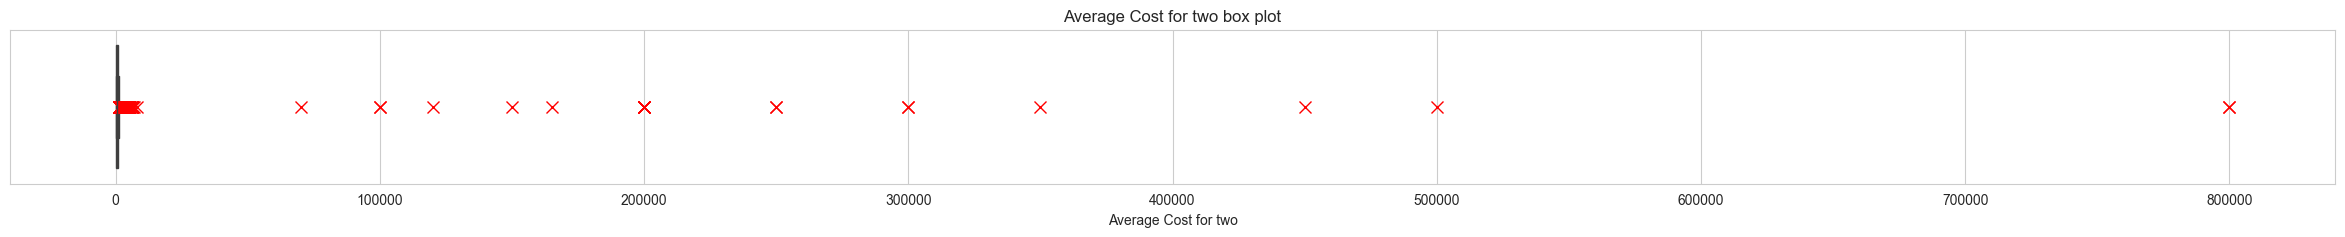

In [109]:
# Box plot
plt.figure(figsize=(30,2))
sns.boxplot(
    x=df['Average Cost for two'],
    flierprops=dict(
        marker='x',
        markeredgecolor='red',
        markersize=8,
        linestyle='none'
    )
)
plt.title('Average Cost for two box plot');

Skewness: 35.5
Kurtosis: 1496.6


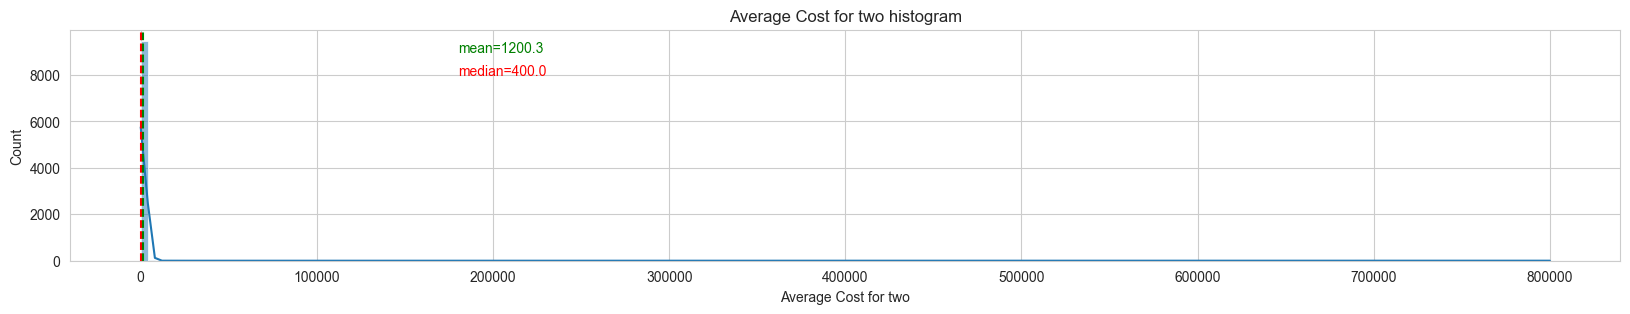

In [110]:
histogrammer('Average Cost for two', median_text=True, mean_text=True, kde=True)

**Observation:**
- This parameter is showing Highly Leptokurtic (i.e. Kurtosis >> 3) distribution.

### **Votes**

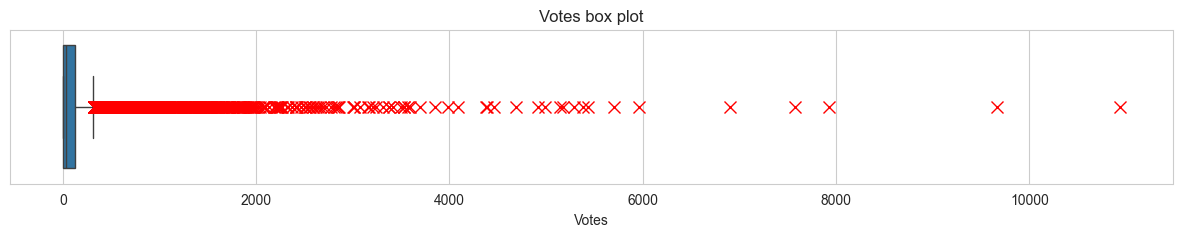

In [111]:
# Box plot
plt.figure(figsize=(15,2))
sns.boxplot(
    x=df['Votes'],
    flierprops=dict(
        marker='x',
        markeredgecolor='red',
        markersize=8,
        linestyle='none'
    )
)
plt.title('Votes box plot');

Skewness: 8.8
Kurtosis: 131.2


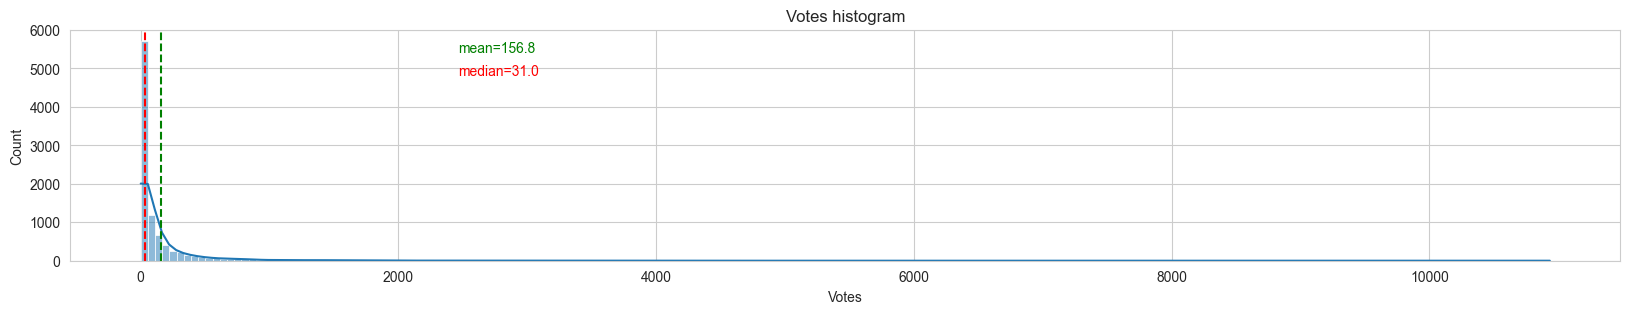

In [112]:
histogrammer('Votes', median_text=True, mean_text=True, kde=True)

**Observation:**
- This parameter is also showing Leptokurtic (i.e. Kurtosis > 3) distribution.

In [113]:
df_1 = df[['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Cuisines', 'Currency']]

df_1.head()

,Restaurant ID,Restaurant Name,Country Code,City,Cuisines,Currency
0,6317637,Le Petit Souffle,162,Makati City,"French, Japanese, Desserts",Botswana Pula(P)
1,6304287,Izakaya Kikufuji,162,Makati City,Japanese,Botswana Pula(P)
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Seafood, Asian, Filipino, Indian",Botswana Pula(P)
3,6318506,Ooma,162,Mandaluyong City,"Japanese, Sushi",Botswana Pula(P)
4,6314302,Sambo Kojin,162,Mandaluyong City,"Japanese, Korean",Botswana Pula(P)


In [114]:
cols = [col for col in df_1.columns if col!='Cuisines']
for col in cols:
    print(f"________________{col}________________")
    print(f"Unique value count: {df_1[col].nunique()}")
    print("="*40)
    print("\n")

________________Restaurant ID________________
Unique value count: 9542


________________Restaurant Name________________
Unique value count: 7437


________________Country Code________________
Unique value count: 15


________________City________________
Unique value count: 140


________________Currency________________
Unique value count: 12




**Observation:**
- As the length of the dataset (i.e. 9542) and the unique Restaurant ID count are same, so we can say that all of the avalilable Restaurant IDs are unique.
- (unique Restaurant Name count) < (unique Restaurant ID count), so we can say that there may be multiple restaurants with same name but unique Restaurant ID.
- (unique Currency count) < (unique Country Code count), so we can say that there are multiple countries with same curreny.

### **Restaurant ID & Restaurant Name**

In [115]:
df_1['Restaurant Name'].value_counts()

Restaurant Name
Cafe Coffee Day      83
Domino's Pizza       79
Subway               63
Green Chick Chop     51
McDonald's           48
                     ..
�ukura��a Sofras۱     1
Gaga Manjero          1
Cafemiz               1
Nusr-Et               1
Maori                 1
Name: count, Length: 7437, dtype: int64

### **Country Code & Currency**

In [116]:
df_1.groupby(by=["Currency",'Country Code'])[['City']].aggregate('count').reset_index()

,Currency,Country Code,City
0,Botswana Pula(P),162,22
1,Brazilian Real(R$),30,60
2,Dollar($),14,24
3,Dollar($),37,4
4,Dollar($),184,20
5,Dollar($),216,425
6,Emirati Diram(AED),214,60
7,Indian Rupees(Rs.),1,8652
8,Indonesian Rupiah(IDR),94,21
9,NewZealand($),148,40


**Observation:**
- Country codes: 14, 37, 184, 216 all have currency as Dollars($)

In [117]:
for col in ["Country Code", "Currency"]:
    print(f"_________________{col}_________________")
    print(df_1[col].value_counts())
    print()
    print(df_1[col].value_counts(normalize=True)*100)
    print("="*35)
    print("\n")

_________________Country Code_________________
Country Code
1      8652
216     425
215      80
30       60
189      60
214      60
148      40
208      34
14       24
162      22
94       21
166      20
184      20
191      20
37        4
Name: count, dtype: int64

Country Code
1     90.673
216    4.454
215    0.838
30     0.629
189    0.629
214    0.629
148    0.419
208    0.356
14     0.252
162    0.231
94     0.220
166    0.210
184    0.210
191    0.210
37     0.042
Name: proportion, dtype: float64


_________________Currency_________________
Currency
Indian Rupees(Rs.)        8652
Dollar($)                  473
Pounds(��)                  80
Brazilian Real(R$)          60
Rand(R)                     60
Emirati Diram(AED)          60
NewZealand($)               40
Turkish Lira(TL)            34
Botswana Pula(P)            22
Indonesian Rupiah(IDR)      21
Qatari Rial(QR)             20
Sri Lankan Rupee(LKR)       20
Name: count, dtype: int64

Currency
Indian Rupees(Rs.)       90.67

Skewness: 3.1
Kurtosis: 10.5


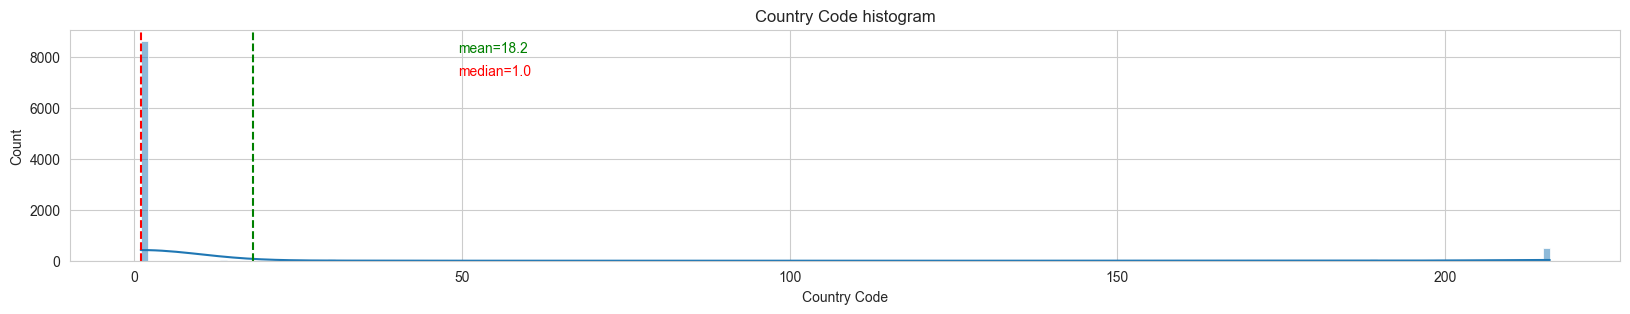

In [118]:
histogrammer("Country Code", kde=True)

Mode: Indian Rupees(Rs.)


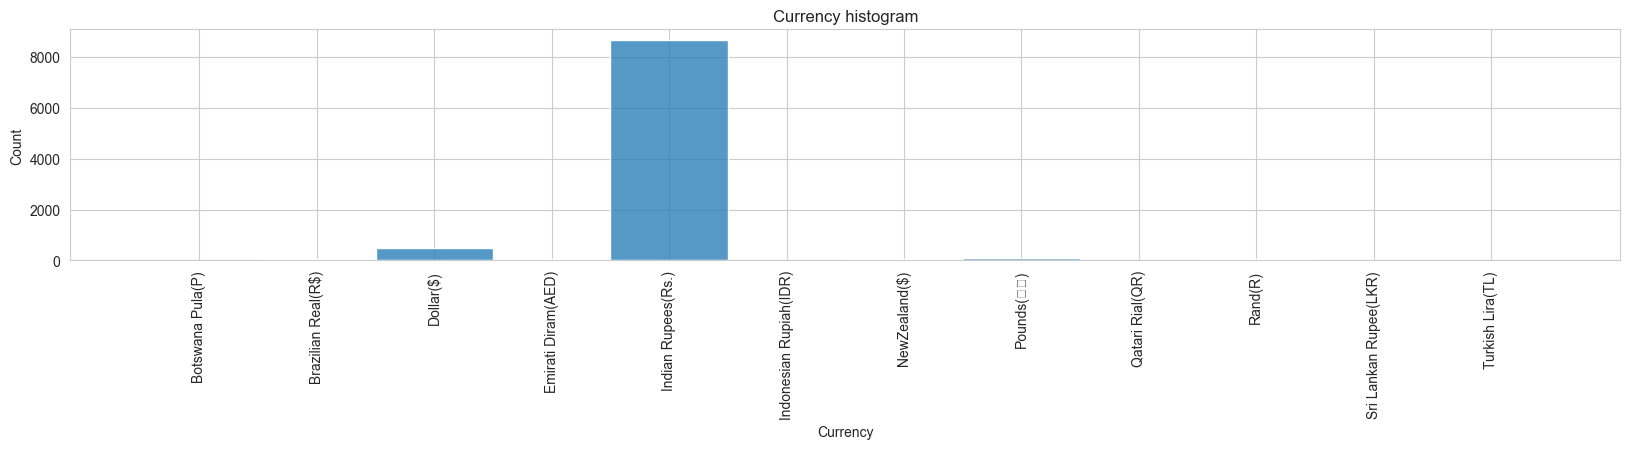

In [119]:
histogrammer("Currency", discrete=True)

### **City**

In [120]:
print(df_1["City"].value_counts())
print("="*35)
print(df_1["City"].value_counts(normalize=True)*100)

City
New Delhi    5473
Gurgaon      1118
Noida        1080
Faridabad     251
Ghaziabad      25
             ... 
Inverloch       1
Mohali          1
Panchkula       1
Bandung         1
Randburg        1
Name: count, Length: 140, dtype: int64
City
New Delhi   57.357
Gurgaon     11.717
Noida       11.318
Faridabad    2.630
Ghaziabad    0.262
             ...  
Inverloch    0.010
Mohali       0.010
Panchkula    0.010
Bandung      0.010
Randburg     0.010
Name: proportion, Length: 140, dtype: float64


Mode: New Delhi


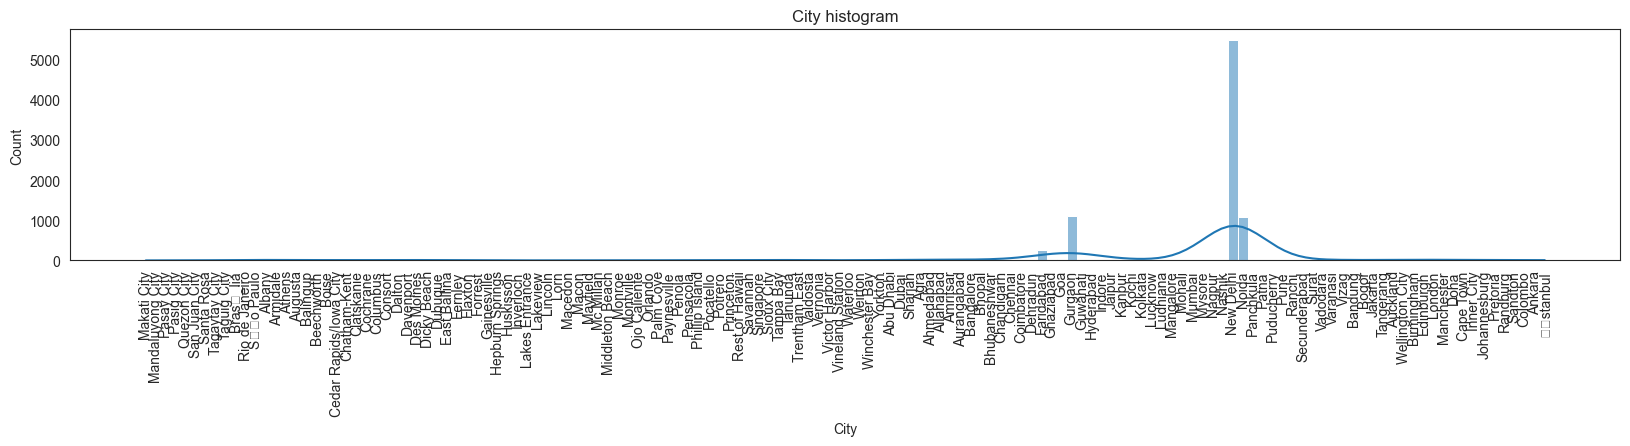

In [121]:
sns.set_style("white")
histogrammer("City", kde=True, discrete=True)

In [122]:
df_city = df_1.groupby(by=['City'])[['Restaurant ID']].aggregate('count')
df_city.sort_values(by='Restaurant ID', ascending=False)

,Restaurant ID
City,
New Delhi,5473
Gurgaon,1118
Noida,1080
Faridabad,251
Ghaziabad,25
...,...
Trentham East,1
Weirton,1
Vineland Station,1


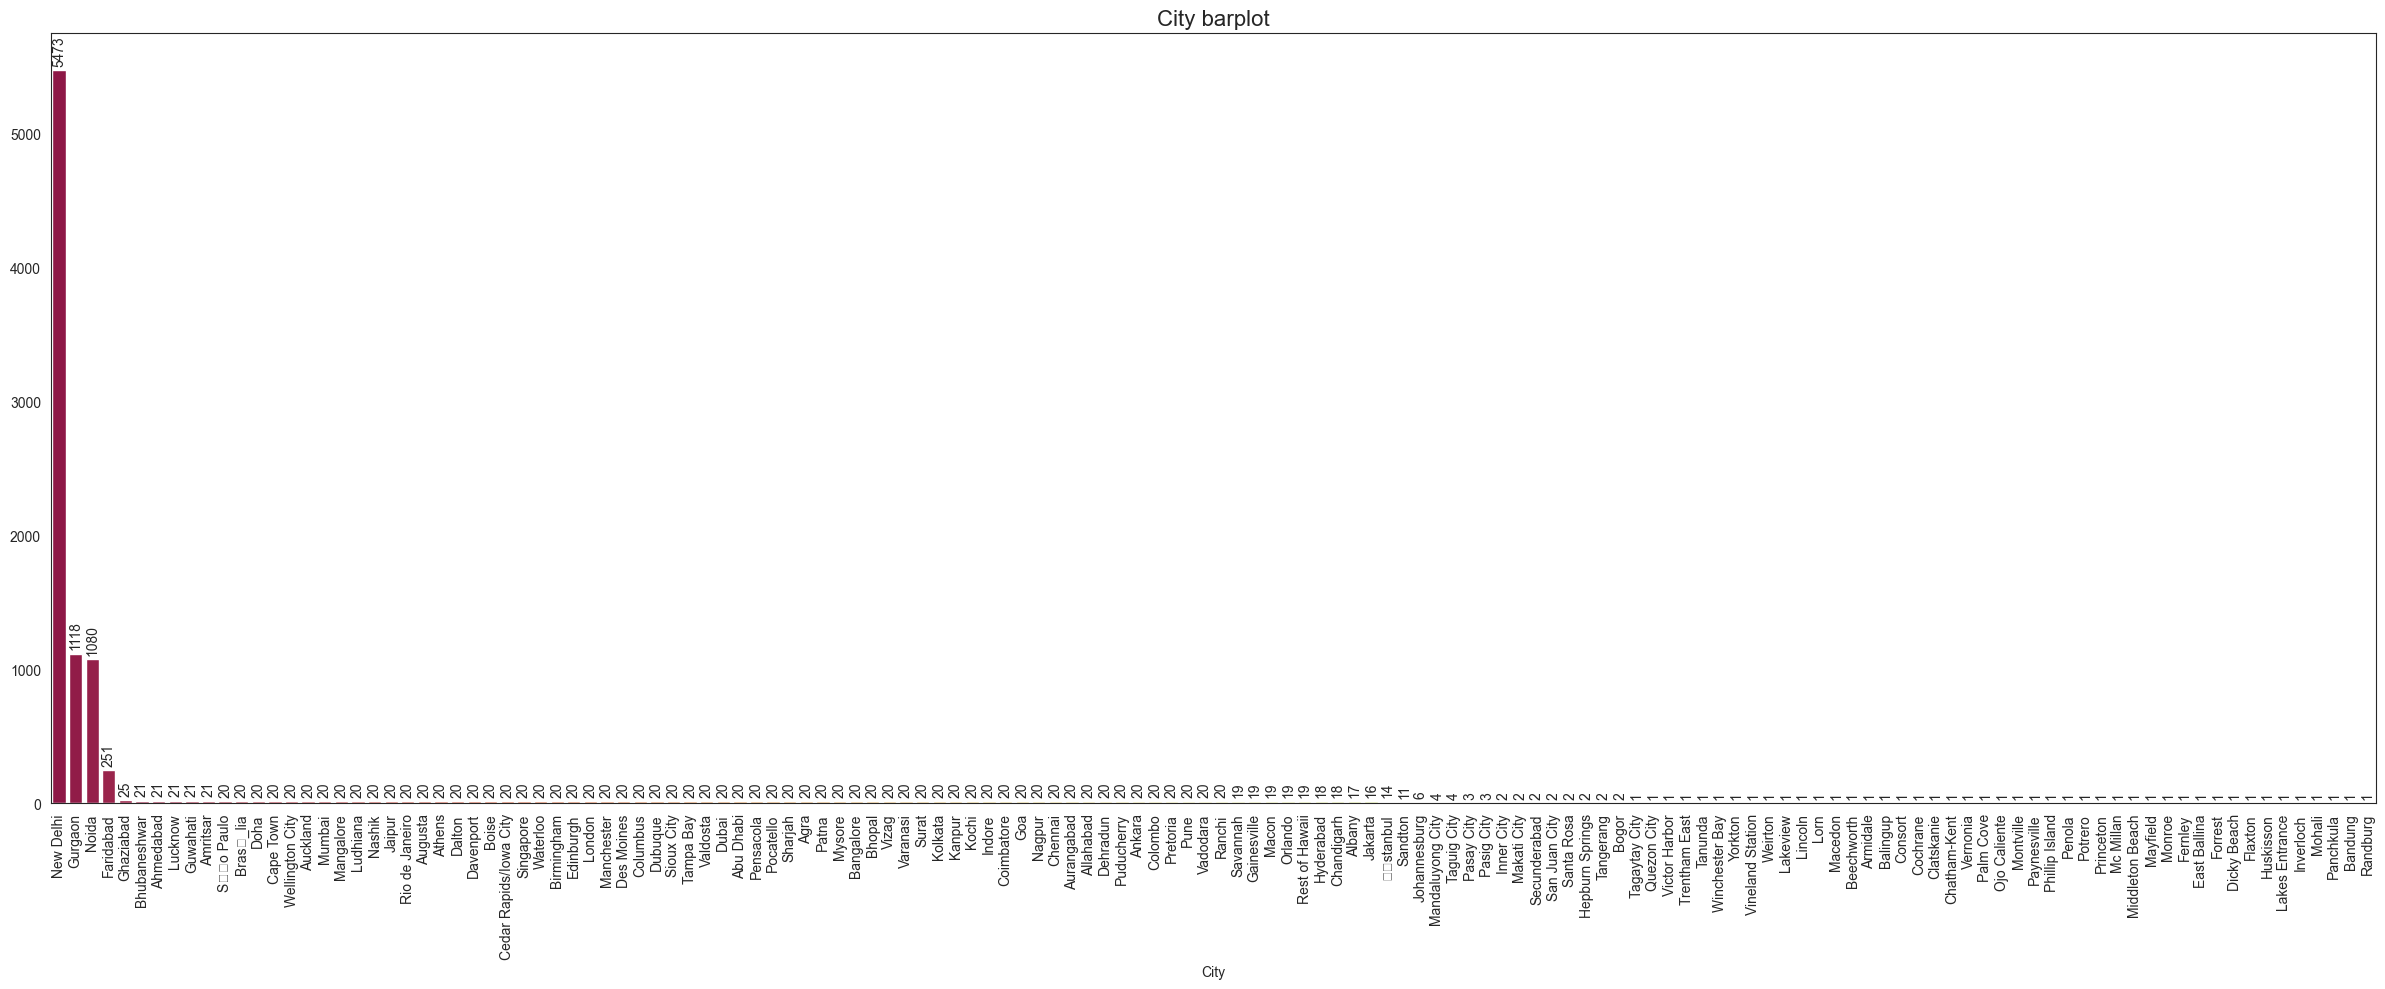

In [123]:
values = df_1["City"].value_counts().values
index = df_1["City"].value_counts().index

plt.figure(figsize=(30,10))
ax = sns.barplot(x=index, 
                 y=values,
                 palette='Spectral',
                 hue=index,
                 legend=False)


for container in ax.containers:
    ax.bar_label(container, padding=3, rotation=90)

plt.xticks(rotation=90)
plt.title('City barplot', fontsize=16);

**Observation:**
1. New Deslhi - 5473
2. Gurgaon - 1118
3. Noida - 1080
4. Faridabad - 251

These 4 cities have huge value counts. So, we can analyze the remaining cities ignoring this 4 for now.

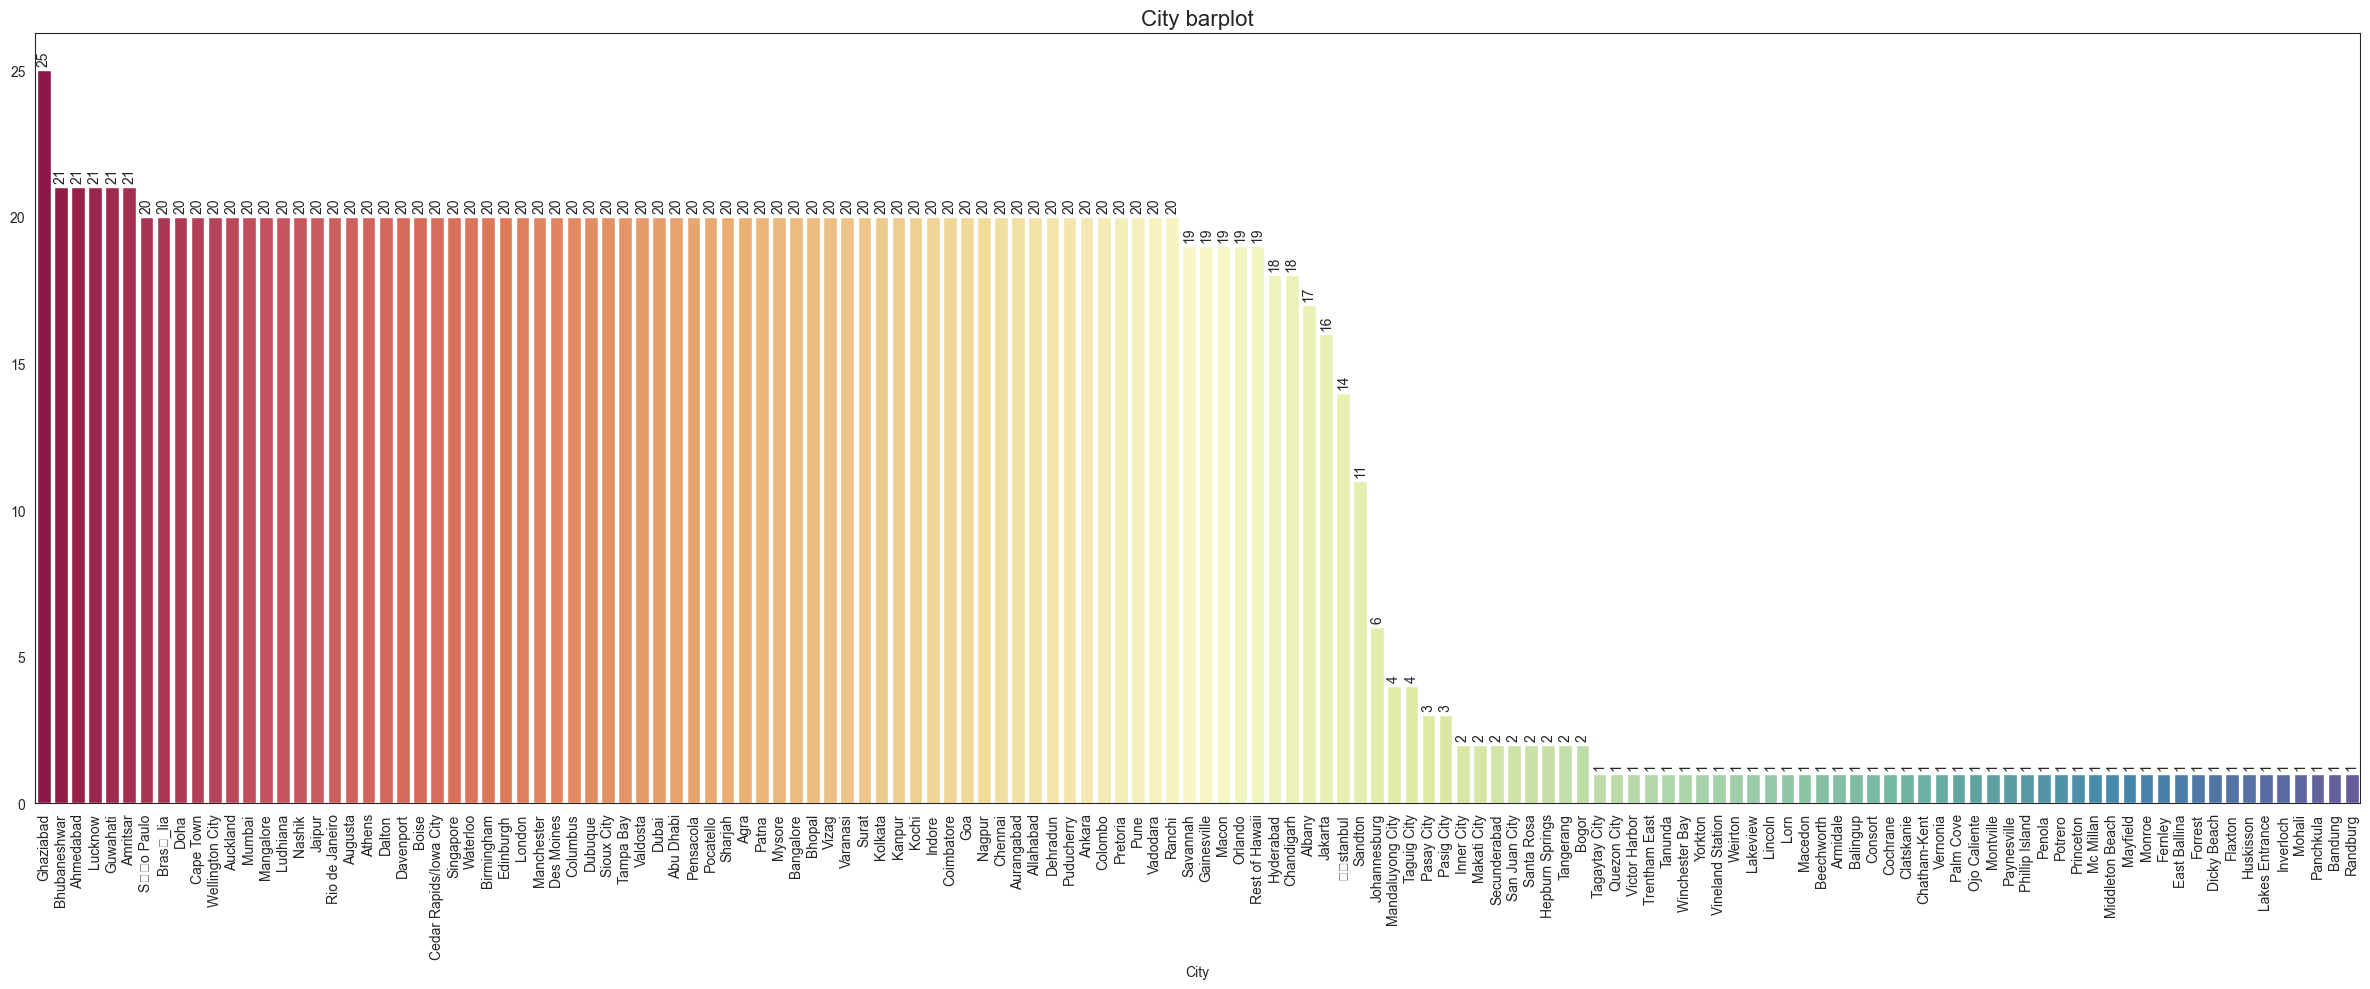

In [124]:
values = df_1["City"].value_counts().values
index = df_1["City"].value_counts().index

plt.figure(figsize=(30,10))
ax = sns.barplot(x=index[4:], 
                 y=values[4:],
                 palette='Spectral',
                 hue=index[4:],
                 legend=False)


for container in ax.containers:
    ax.bar_label(container, padding=3, rotation=90)

plt.xticks(rotation=90)
plt.title('City barplot', fontsize=16);

### **Cuisines**

In [125]:
# Filtering unique Cuisines

unique_cuisines = [] # initializing an empty list
for data in df_1['Cuisines'].str.split(', '):
    unique_cuisines.extend(data)

print(set(unique_cuisines)) # Unique cusisines
print("Available unique cuisines: {}".format(len(set(unique_cuisines)))) # No. of unique cuisines

{'Sri Lankan', 'Izgara', 'Parsi', 'Burmese', 'Fusion', 'Scottish', 'Taiwanese', 'Healthy Food', 'Kiwi', 'Modern Indian', 'Rajasthani', 'Hawaiian', 'Caribbean', 'Malwani', 'Canadian', 'Desserts', 'Lucknowi', 'North Indian', 'Bar Food', 'Greek', 'Western', 'Beverages', 'Assamese', 'Bihari', 'Mineira', 'Ramen', 'Restaurant Cafe', 'Armenian', 'Modern Australian', 'Andhra', 'Drinks Only', 'Brazilian', 'Asian', 'Naga', 'Southwestern', 'Lebanese', 'Teriyaki', 'German', 'Indonesian', 'Filipino', 'North Eastern', 'Grill', 'Kerala', 'Thai', 'Salad', 'Singaporean', 'American', 'D�_ner', 'French', 'BBQ', 'Cajun', 'New American', 'Coffee and Tea', 'Malay', 'Australian', 'South African', 'British', 'Gujarati', 'Fast Food', 'Tex-Mex', 'International', 'Maharashtrian', 'Charcoal Grill', 'European', 'Steak', 'Tibetan', 'Peranakan', 'South American', 'Kashmiri', 'African', 'Pub Food', 'Moroccan', 'Juices', 'Korean', 'Mithai', 'Bengali', 'Dim Sum', 'Bakery', 'Gourmet Fast Food', 'Burger', 'Biryani', 'Ira

In [126]:
len(unique_cuisines)

19710

In [127]:
df_cuisines = pd.DataFrame(data=unique_cuisines, columns=['available_cuisines'])
df_cuisines

,available_cuisines
0,French
1,Japanese
2,Desserts
3,Japanese
4,Seafood
...,...
19705,Cafe
19706,Italian
19707,World Cuisine
19708,Restaurant Cafe


In [128]:
print(df_cuisines.value_counts().reset_index())
print()
display(df_cuisines.value_counts(normalize=True)*100)

    available_cuisines  count
0         North Indian   3960
1              Chinese   2735
2            Fast Food   1986
3              Mughlai    995
4              Italian    764
..                 ...    ...
140            Mineira      1
141              Malay      1
142           Peruvian      1
143            Malwani      1
144          Soul Food      1

[145 rows x 2 columns]



available_cuisines
North Indian         20.091
Chinese              13.876
Fast Food            10.076
Mughlai               5.048
Italian               3.876
                      ...  
Mineira               0.005
Malay                 0.005
Peruvian              0.005
Malwani               0.005
Soul Food             0.005
Name: proportion, Length: 145, dtype: float64

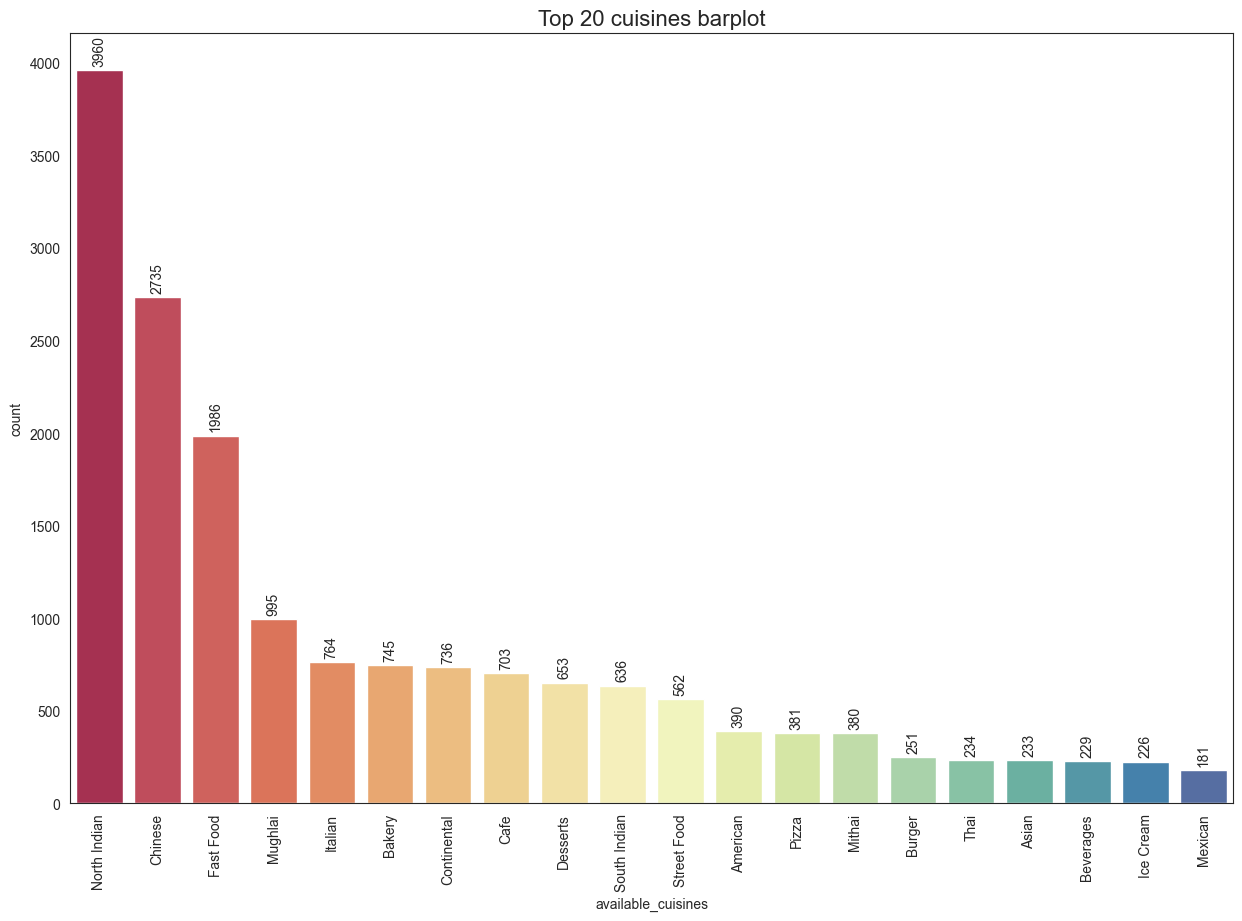

In [129]:
# visualizing top 20 cuisisnes
data = df_cuisines.value_counts().reset_index()
index = data['available_cuisines']
values = data['count']

plt.figure(figsize=(15,10))
ax = sns.barplot(x=index[:20], 
                 y=values[:20],
                 palette='Spectral',
                 hue=index[:20],
                 legend=False)


for container in ax.containers:
    ax.bar_label(container, padding=3, rotation=90)

plt.xticks(rotation=90)
plt.title('Top 20 cuisines barplot', fontsize=16)
base_path = Path.cwd().parents[1]
file_path = base_path / "Notebooks" / "reports" / "Top 20 cuisines barplot.png"
plt.savefig(file_path, dpi=150, bbox_inches='tight');

# Task - 3: **Geospatial Analysis**

In [130]:
import plotly.io as pio
pio.renderers.default = 'notebook'

In [131]:
import nbformat
print(nbformat.__version__)

5.10.4


In [132]:
import plotly.io as pio
pio.renderers.default = "vscode"

In [133]:
fig = px.scatter_mapbox(
    df,
    lat='Latitude',
    lon='Longitude',
    hover_name='Restaurant Name',
    hover_data=['City', 'Cuisines', 'Aggregate rating'],
    color='Aggregate rating',
    color_continuous_scale='RdYlGn',
    size='Votes',
    zoom=2,
    mapbox_style='open-street-map',
    title='Restaurant Locations by Rating'
)

fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

In [134]:
df2 = df.groupby(by=['Country Code', 'City'])[['Restaurant ID']].aggregate('count').sort_values(by='Restaurant ID', ascending=False)

with pd.option_context('display.max_rows', None):
    display(df2)

Restaurant ID
Country Code City                                 
1            New Delhi                        5473
             Gurgaon                          1118
             Noida                            1080
             Faridabad                         251
             Ghaziabad                          25
             Ahmedabad                          21
             Guwahati                           21
             Lucknow                            21
             Bhubaneshwar                       21
             Amritsar                           21
             Allahabad                          20
             Agra                               20
189          Pretoria                           20
1            Dehradun                           20
             Coimbatore                         20
             Chennai                            20
             Bhopal                             20
             Bangalore                          20
             Aurangabad                         20
             Goa                                20
             Ludhiana                           20
             Kanpur                             20
             Kochi                              20
             Kolkata                            20
             Mumbai                             20
             Mangalore                          20
             Jaipur                             20
             Indore                             20
             Vizag                              20
             Ranchi                             20
             Nagpur                             20
             Mysore                             20
             Nashik                             20
             Patna                              20
             Puducherry                         20
             Pune                               20
             Varanasi                           20
             Vadodara                           20
             Surat                              20
30           Rio de Janeiro                     20
             S��o Paulo                         20
             Bras�_lia                          20
148          Wellington City                    20
             Auckland                           20
215          London                             20
214          Abu Dhabi                          20
216          Augusta                            20
             Boise                              20
             Davenport                          20
             Dalton                             20
             Cedar Rapids/Iowa City             20
             Columbus                           20
             Sioux City                         20
             Tampa Bay                          20
             Valdosta                           20
             Waterloo                           20
             Pocatello                          20
             Pensacola                          20
             Dubuque                            20
             Des Moines                         20
184          Singapore                          20
215          Manchester                         20
208          Ankara                             20
191          Colombo                            20
215          Edinburgh                          20
             Birmingham                         20
214          Sharjah                            20
             Dubai                              20
216          Athens                             20
189          Cape Town                          20
166          Doha                               20
216          Rest of Hawaii                     19
             Gainesville                        19
             Macon                              19
             Orlando                            19
             Savannah                           19
1            Chandigarh                         18
        

In [135]:
# Correlation
corr = df[['Latitude', 'Longitude', 'Aggregate rating']].corr()
print("Correlation with Aggregate rating:")
display(corr.round(3))

# City-level stats
city_stats = (
    df.groupby('City')
    .agg(avg_rating=('Aggregate rating', 'mean'),
         count=('Aggregate rating', 'count'))
    .query('count >= 20')
    .sort_values('avg_rating', ascending=False)
    .head(20)
)

# Summary table
print("\nTop 20 cities by average rating (min 20 restaurants):")
print(city_stats.round(2).to_string())

Correlation with Aggregate rating:


,Latitude,Longitude,Aggregate rating
Latitude,1.000,0.045,0.000
Longitude,0.045,1.000,-0.115
Aggregate rating,0.000,-0.115,1.000



Top 20 cities by average rating (min 20 restaurants):
                 avg_rating  count
City                              
London                4.540     20
Tampa Bay             4.410     20
Bangalore             4.380     20
Dubai                 4.370     20
Chennai               4.310     20
Ankara                4.300     20
Abu Dhabi             4.300     20
Auckland              4.280     20
Rio de Janeiro        4.260     20
Boise                 4.260     20
Kolkata               4.260     20
Wellington City       4.250     20
Goa                   4.240     20
Des Moines            4.240     20
Pune                  4.220     20
Athens                4.200     20
Pensacola             4.200     20
Lucknow               4.200     21
Guwahati              4.190     21
Pretoria              4.190     20


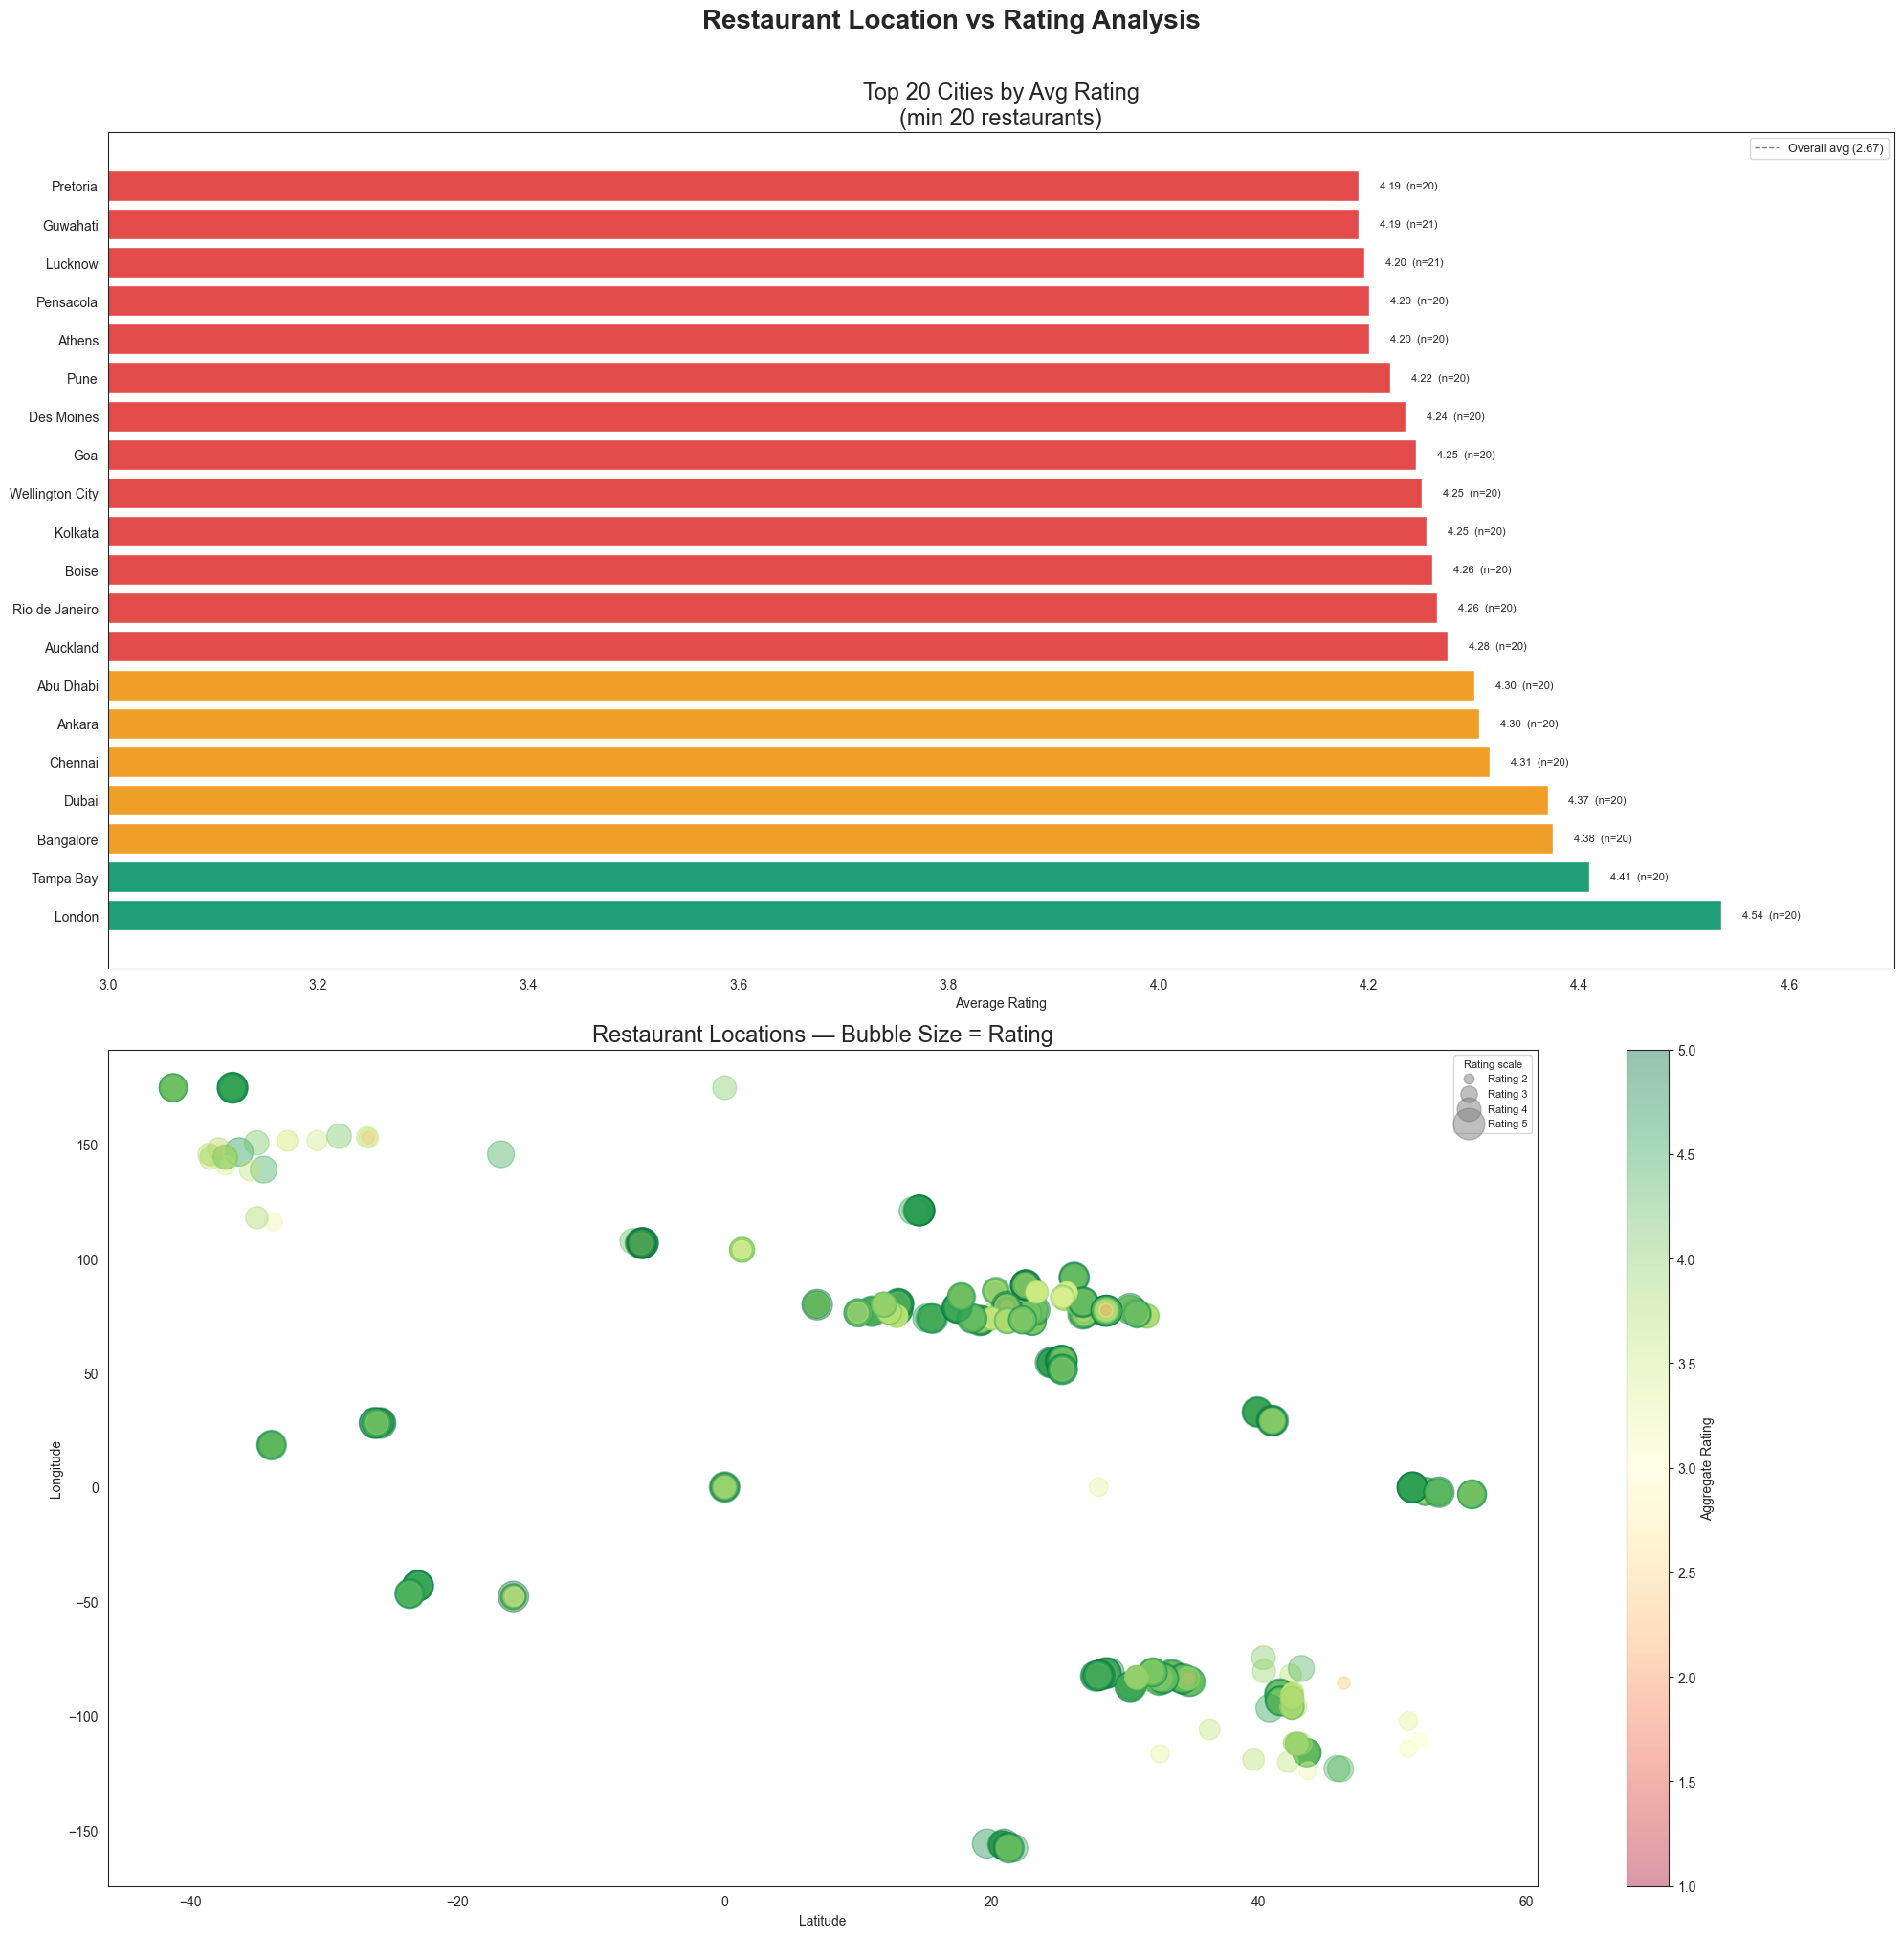

In [136]:
# Plot: Rating by City (bar chart)
fig, axes = plt.subplots(2, 1, figsize=(20, 20))
fig.suptitle('Restaurant Location vs Rating Analysis', fontsize=20, fontweight='bold', y=1.01)

colors=[]
for v in city_stats['avg_rating']:
    if v >= 4.4:
        colors.append('#1D9E75')
    elif (4.4 > v >= 4.3):
        colors.append('#EF9F27')
    else:
        colors.append('#E24B4A')

axes[0].barh(city_stats.index, city_stats['avg_rating'], color=colors, edgecolor='white')
axes[0].set_xlabel('Average Rating')
axes[0].set_title('Top 20 Cities by Avg Rating\n(min 20 restaurants)', fontsize=17)
axes[0].set_xlim(3.0, 4.7)
axes[0].axvline(x=df['Aggregate rating'].mean(), color='gray', linestyle='--',
                linewidth=1, label=f"Overall avg ({df['Aggregate rating'].mean():.2f})")
axes[0].legend(fontsize=9)

# Add value labels
for i, (val, cnt) in enumerate(zip(city_stats['avg_rating'], city_stats['count'])):
    axes[0].text(val + 0.02, i, f'{val:.2f}  (n={cnt})', va='center', fontsize=8)

# Plot: Latitude (x) vs Longitude (y), bubble size = Aggregate Rating
bubble_size = df['Aggregate rating'] ** 2.5 * 10  # scale up for visibility

sc = axes[1].scatter(df['Latitude'], df['Longitude'],
                     alpha=0.4, s=bubble_size, c=df['Aggregate rating'],
                     cmap='RdYlGn', vmin=1, vmax=5)

axes[1].set_xlabel('Latitude')
axes[1].set_ylabel('Longitude')
axes[1].set_title('Restaurant Locations — Bubble Size = Rating', fontsize=17)
plt.colorbar(sc, ax=axes[1], label='Aggregate Rating')

# Add a legend showing bubble sizes
for rating in [2, 3, 4, 5]:
    axes[1].scatter([], [], s=rating**2.5 * 10, c='gray', alpha=0.5, label=f'Rating {rating}')
axes[1].legend(title='Rating scale', fontsize=8, title_fontsize=8)

plt.tight_layout()
base_path = Path.cwd().parents[1]  # go up two levels
file_path = base_path / "Notebooks" / "reports" / "location_vs_rating.png"
plt.savefig(file_path, dpi=150, bbox_inches='tight')
plt.show()

**Observation:**
- There is a weak correlation, but location alone doesn't drive ratings. The correlation coefficients are 0.00 (latitude) and −0.12 (longitude), meaning higher-longitude cities (further east) tend to score slightly lower — but the relationship is too weak to be predictive.
- The more interesting story is city-level differences:
  * International cities (Abu Dhabi, Ankara, Athens) cluster around 4.2–4.3, significantly above average. These likely have fewer but better-quality restaurants in the dataset.
  * Indian metro cities (New Delhi, Noida, Gurgaon, Faridabad, Chennai) average 3.1–3.3. They dominate the dataset in volume (~5,600 restaurants) which drags the average down.
  * This is largely a data composition effect — India has ~90% of all restaurants in this dataset, so the overall averages are skewed by them.